# Praktikum Praproses Data

Nama : Levina Zahrathul Huda \
NRP  : 5054251033

# Unduh dan Import Dataset

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
df = pd.read_csv('train.csv')

df.head()
print("Jumlah baris dan kolom:", df.shape)
df.info()

Jumlah baris dan kolom: (1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null

# Pembersihan Data

In [149]:
# Periksa jumlah missing values

missing = df.isna().sum()
missing = missing[missing > 0]
print(missing)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


Berdasarkan data, atribut dengan proporsi missing value yang lebih dari 50% yaitu:
- Alley
- MasVnrType
- PoolQC
- Fence
- MiscFeature

In [150]:
# Hapus kolom/atribut dengan proporsi nilai hilang lebih dari 50%

df = df.drop(columns=['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'])
print("Jumlah baris dan kolom setelah penghapusan:", df.shape)

Jumlah baris dan kolom setelah penghapusan: (1460, 76)


Jumlah baris dan kolom awal adalah 1460 baris dan 81 kolom. Setelah menghapus kolom dengan proporsi missing values lebih dari 50%, jumlah baris dan kolom menjadi 1460 dan 76. Di sini, jumlah kolom berkurang sebanyak 5 buah.

Setelah menghapus 5 buah kolom, masih terdapat missing value lainnya yang tidak lebih dari 50%. Missing values ini kemudian ditangani pada langkah selanjutnya.

In [151]:
# Missing value pada atribut numerik
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)


# Missing value pada atribut kategorikal
df['BsmtQual'] = df['BsmtQual'].fillna('None')
df['BsmtCond'] = df['BsmtCond'].fillna('None')
df['BsmtExposure'] = df['BsmtExposure'].fillna('None')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
df['GarageType'] = df['GarageType'].fillna('None')
df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageQual'] = df['GarageQual'].fillna('None')
df['GarageCond'] = df['GarageCond'].fillna('None')
df['Electrical'] = df['Electrical'].fillna(df["Electrical"].mode()[0])

# Cek hasil akhir missing value
print("Jumlah missing value:") 
print(df.isna().sum())

Jumlah missing value:
Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64


# Deteksi dan Penanganan Outlier

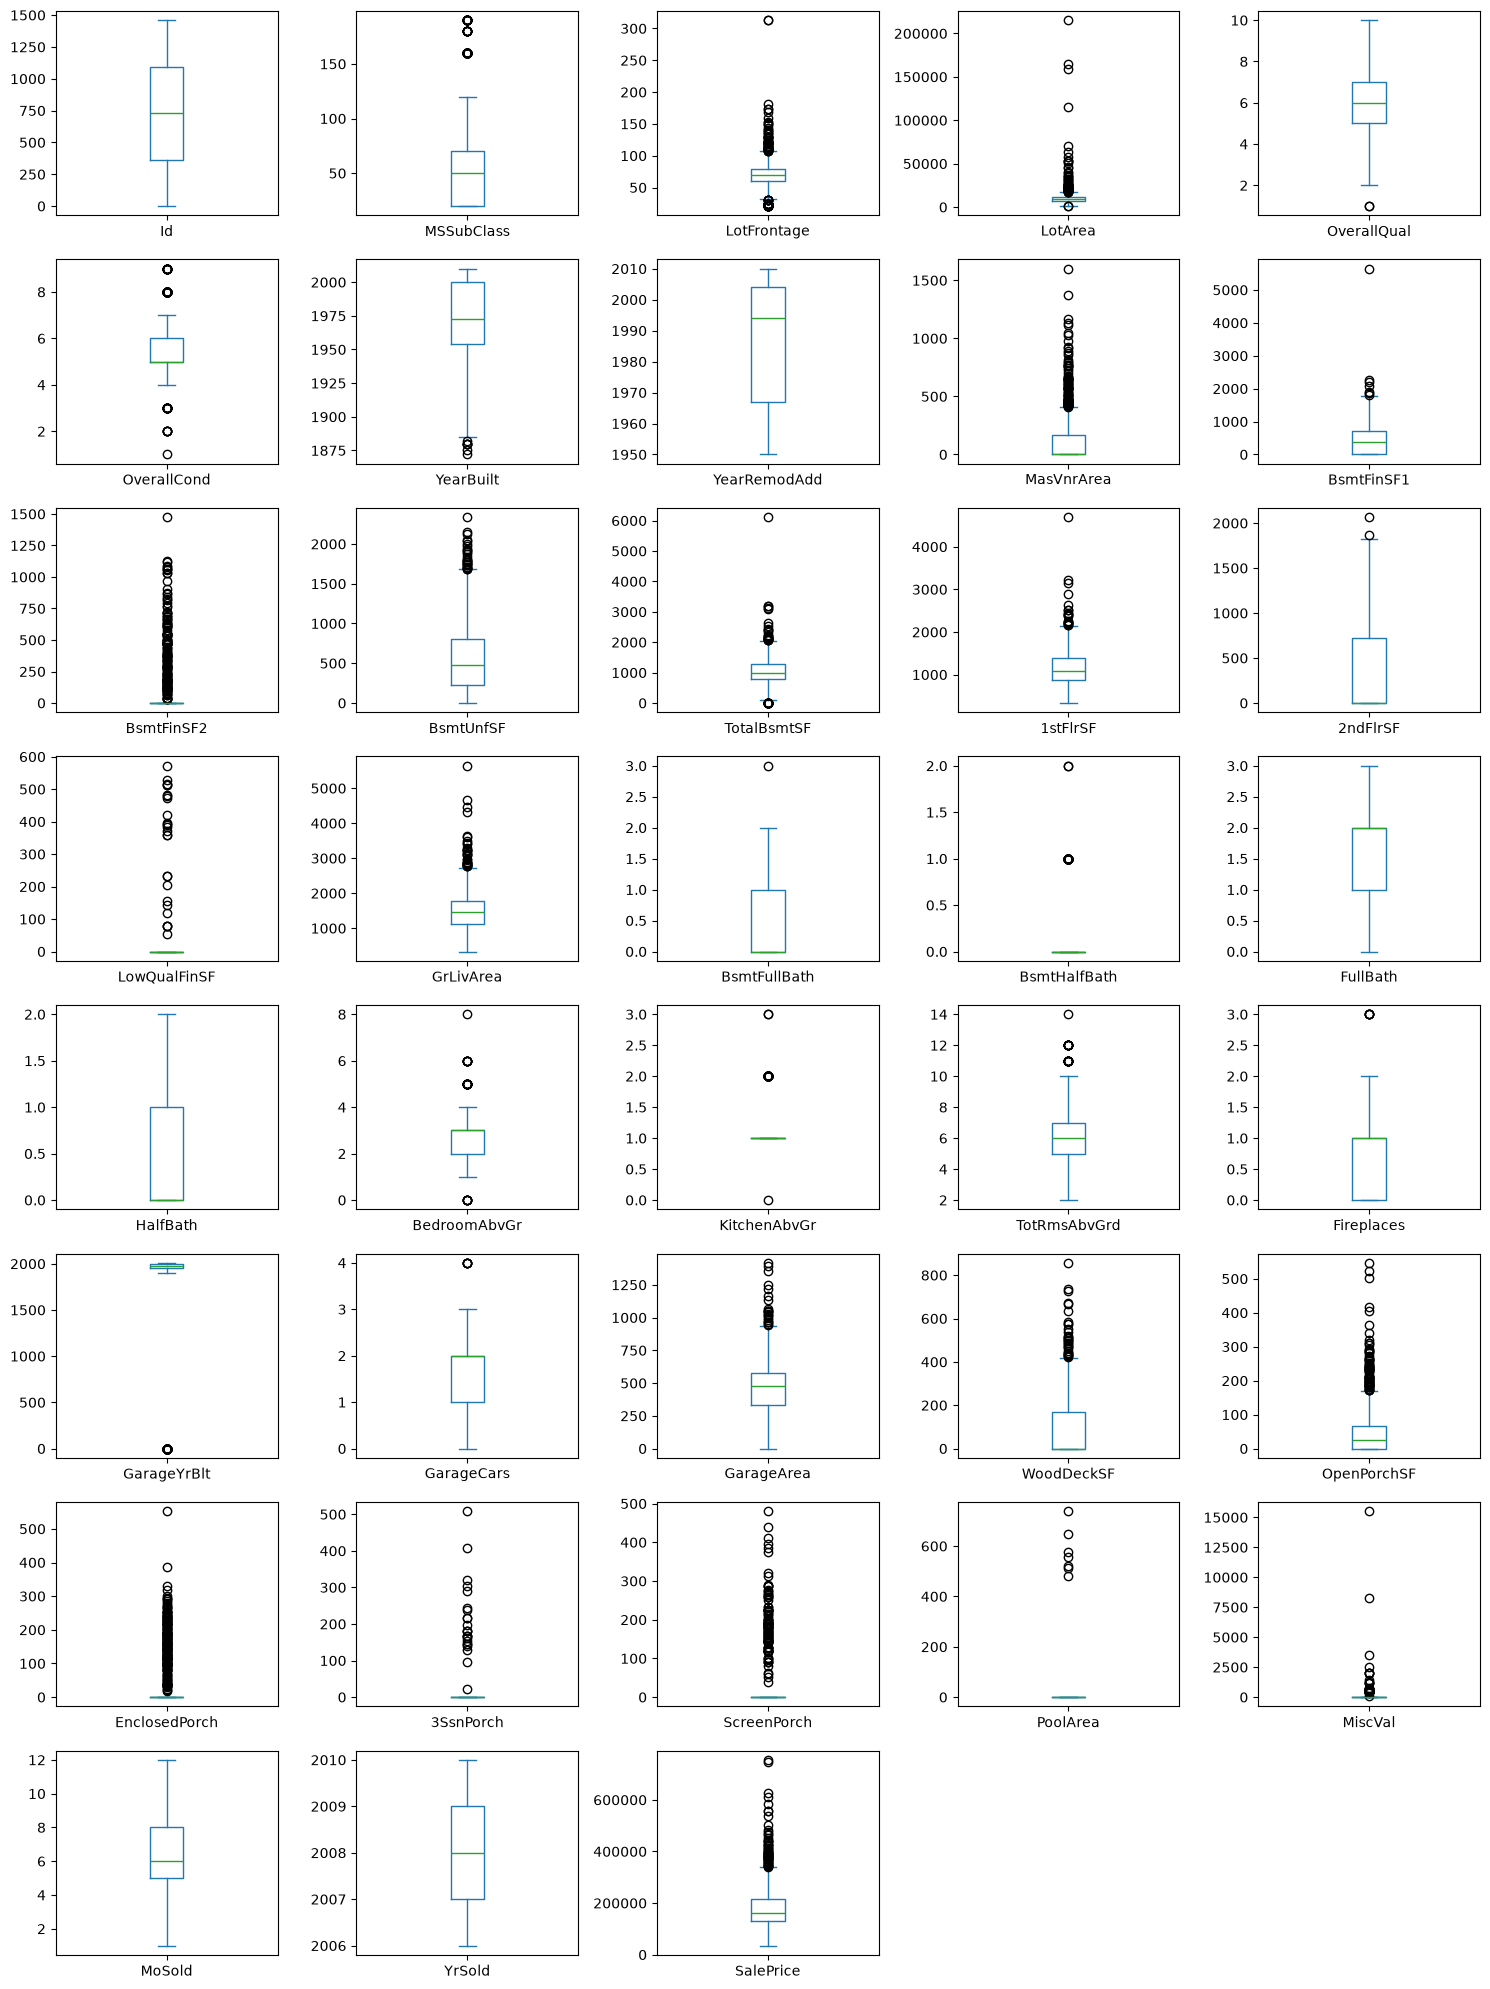

In [152]:
# Boxplot atribut numerik
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns].plot(
    kind='box',
    subplots=True,
    layout=(8, 5),
    figsize=(15, 20),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boxplot GrLivArea')

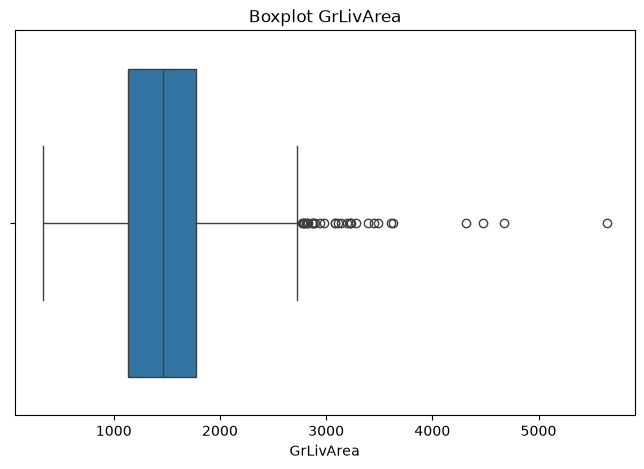

In [153]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['GrLivArea'])
plt.title("Boxplot GrLivArea")

In [154]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)

IQR = Q3 - Q1
batas_atas = Q3 + 1.5*IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas atas:", batas_atas)

Q1: 1129.5
Q3: 1776.75
IQR: 647.25
Batas atas: 2747.625


In [155]:
outlier = df[df['GrLivArea'] > batas_atas]
print("Jumlah outlier:", len(outlier))
outlier[['GrLivArea', 'SalePrice']]

Jumlah outlier: 31


,GrLivArea,SalePrice
58,2945,438780
118,3222,320000
185,3608,475000
197,3112,235000
231,2794,403000
304,3493,295000
324,2978,242000
496,3228,430000
523,4676,184750
583,2775,325000


In [156]:
# Penanganan outlier dengan adjusting outlier (Capping)

df['GrLivArea'] = df['GrLivArea'].clip(upper=batas_atas)
print(df.shape)
print(df['GrLivArea'].max())

(1460, 76)
2747.625


Text(0.5, 1.0, 'Boxplot GrLivArea Setelah Capping')

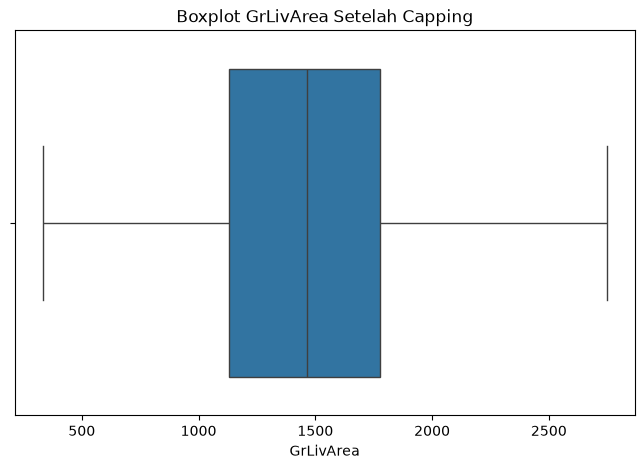

In [157]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['GrLivArea'])
plt.title('Boxplot GrLivArea Setelah Capping')

In [158]:
# Menyimpan dataset hasil cleaning
df.to_csv("5054251033_Levina Zahrathul Huda_Tugas_Praproses_Data.csv", index=False)
print("Dataset hasil cleaning berhasil disimpan.")

Dataset hasil cleaning berhasil disimpan.


# Transformasi Data


In [159]:
# Pemisahan X (Fitur (Informasi untuk bahan prediksi)) & y (Target (Yang ingin diprediksi))
X = df.drop(columns=['SalePrice', 'Id'])   # X = fitur
y = df['SalePrice']   # y = target

print(X.shape)
print(y.shape)

(1460, 74)
(1460,)


In [160]:
# Encoding menggunakan One-Hot Encoding
X = pd.get_dummies(X, dtype=int)
print("Ukuran X setelah One-Hot Encoding:", X.shape)

Ukuran X setelah One-Hot Encoding: (1460, 281)


In [161]:
# Standardisasi atribut
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ukuran data setelah standardisasi:", X_scaled.shape)
print("Rata-rata data:", X_scaled.mean())
print("Standar deviasi data:", X_scaled.std())

Ukuran data setelah standardisasi: (1460, 281)
Rata-rata data: 1.6091387310357067e-16
Standar deviasi data: 1.0


# Reduksi Dimensi

Text(0.5, 1.0, 'Correlation Heatmap')

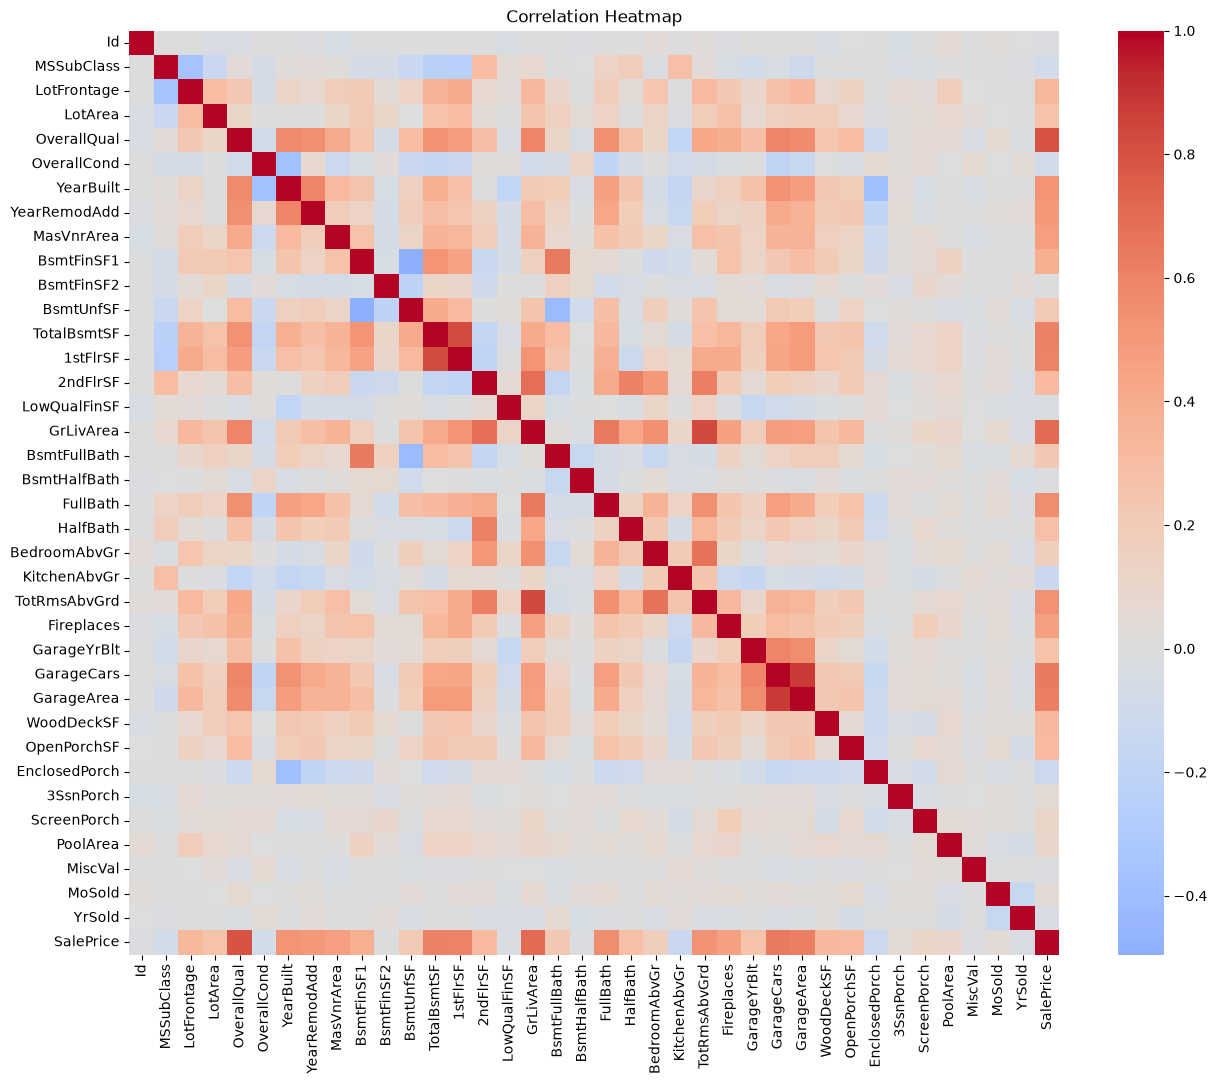

In [162]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(15, 12))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")

Kemudian, cari pasangan dengan korelasi tinggi:

In [163]:
corr_matrix = numeric_df.corr().abs()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] >= 0.8:
            high_corr.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                )
            )

high_corr

[('1stFlrSF', 'TotalBsmtSF', np.float64(0.8195299750050339)),
 ('TotRmsAbvGrd', 'GrLivArea', np.float64(0.835567760550734)),
 ('GarageArea', 'GarageCars', np.float64(0.882475414281462))]

Terdapat 3 pasangan yang berkorelasi tinggi, yaitu `1stFlrSF` dan `TotalBsmtSF` dengan korelasi 0.8195, lalu `TotRmsAbvGrd` dan `GrLivArea` dengan korelasi 0.8356, serta `GarageArea` dan `GarageCars` dengan korelasi 0.8825. Selanjutnya, buang salah satu atribut jika perlu.

In [164]:
# Membuang atribut yang berkorelasi tinggi
X = X.drop(columns=['TotalBsmtSF', 'TotRmsAbvGrd', 'GarageArea'])
print("Ukuran X setelah pengurangan atribut:", X.shape)

Ukuran X setelah pengurangan atribut: (1460, 278)


Pada atribut `1stFlrSF` dan `TotalBsmtSF`, keduanya berhubungan dengan luas area bangunan, sehingga informasinya cukup berkaitan. Maka, `1stFlrSF` dipertahankan dan `TotalBsmtSF` dibuang. Kemudian, `TotRmsAbvGrd` yaitu jumlah ruangan di atas permukaan tanah dan `GrLivArea` yaitu luas area tempat tinggal di atas permukaan tanah. Keduanya berhubungan dengan ukuran ruang tinggal. Pada analisis outlier sebelumnya atribut `GrLivArea` sudah digunakan, maka `GrLivArea` dipertahankan dan `TotRmsAbvGrd` dibuang. Selanjutnya, `GarageArea` yaitu luas garasi dan `GarageCars` yaitu kapasitas garasi. `GarageArea` dipertahankan dan `GarageCars` dibuang.

In [165]:
# Standardisasi ulang
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ukuran X setelah stadardisasi:", X_scaled.shape)

Ukuran X setelah stadardisasi: (1460, 278)


Melakukan standardisasi ulang karena jumlah atribut berkurang.

In [166]:
# PCA untuk mengurangi dimensi data
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("Jumlah fitur sebelum PCA:", X_scaled.shape[1])
print("Jumlah komponen setelah PCA:", X_pca.shape[1])

Jumlah fitur sebelum PCA: 278
Jumlah komponen setelah PCA: 170


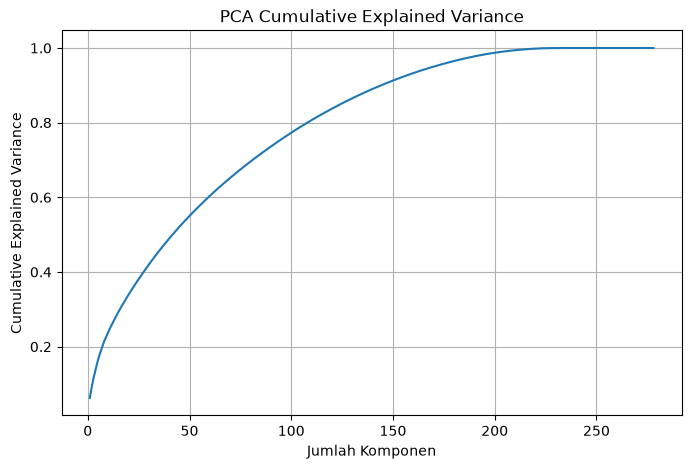

In [167]:
# Visualisasi PCA
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid()

In [168]:
print("Ukuran data hasil PCA:", X_pca.shape)
print("Ukuran dataset cleaning:", df.shape)
print("Jumlah missing value:", df.isna().sum().sum())

Ukuran data hasil PCA: (1460, 170)
Ukuran dataset cleaning: (1460, 76)
Jumlah missing value: 0
